## Павлусенко Ангеліна КН-42-15
Мета:Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

## Набір даних MNIST містить зображення рукописних цифр від 0 до 9.  Кожне зображення має розмір 28×28 пікселів, що відповідає 784 ознакам у векторному вигляді.

In [37]:
#1 завдання 
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [38]:
print(X.shape)

(70000, 784)


## Для попереднього аналізу даних було виведено кілька випадкових прикладів цифр з набору MNIST.  Це дозволяє побачити структуру даних та зрозуміти, як виглядають зображення у вигляді матриці 28×28.

In [39]:
import numpy as np

print("Unique labels:", np.unique(y).size)
print("Labels:", np.unique(y))

Unique labels: 10
Labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


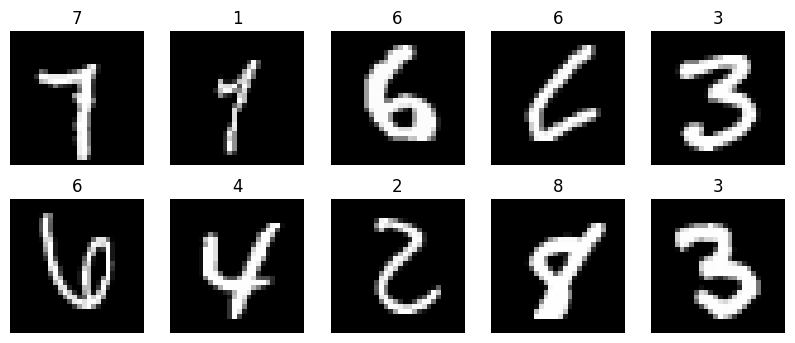

In [40]:
import matplotlib.pyplot as plt

indices = np.random.choice(X.shape[0], 10)

fig, axes = plt.subplots(2, 5, figsize=(10,4))

for ax, i in zip(axes.flat, indices):
    ax.imshow(X[i].reshape(28,28), cmap="gray")
    ax.set_title(y[i])
    ax.axis("off")

plt.show()

## Метод головних компонент (Principal Component Analysis) використовується для зменшення розмірності даних.  У даній роботі кількість вимірів зменшується з 784 до 3, що дозволяє виконати візуалізацію у тривимірному просторі.

In [41]:
#2 завдання
from sklearn.decomposition import PCA

In [42]:
pca = PCA(n_components=3)

In [43]:
X_pca = pca.fit_transform(X)

In [44]:
print(X_pca.shape)

(70000, 3)


In [45]:
print(pca.explained_variance_ratio_)

[0.09746116 0.07155445 0.06149531]


## Після зменшення розмірності дані було відображено у просторі трьох головних компонент (PC1, PC2, PC3).  Кожна точка відповідає одному зображенню цифри, а її колір відповідає класу цифри.

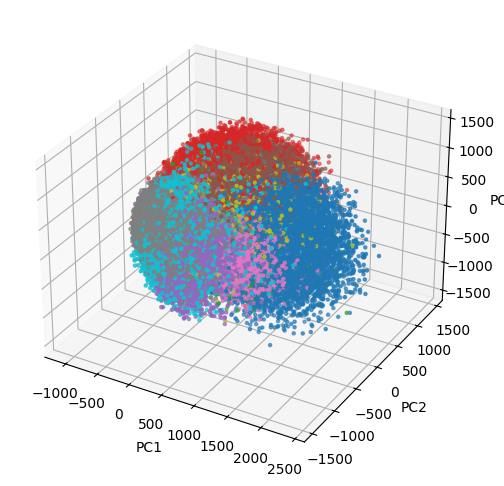

In [46]:
#3 завдання
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y.astype(int),
    cmap='tab10',
    s=5
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

## Після зменшення розмірності зображення були відновлені у початковий простір за допомогою методу `inverse_transform()`.Порівняння оригінальних та реконструйованих зображень дозволяє оцінити втрату інформації після застосування PCA.

In [47]:
X_reconstructed = pca.inverse_transform(X_pca)

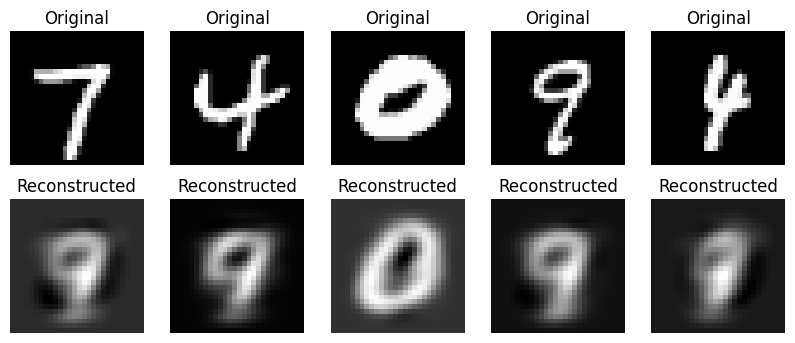

In [48]:
fig, axes = plt.subplots(2,5, figsize=(10,4))

indices = np.random.choice(X.shape[0], 5)

for i, idx in enumerate(indices):
    
    # оригінал
    axes[0,i].imshow(X[idx].reshape(28,28), cmap="gray")
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")
    
    # реконструкція
    axes[1,i].imshow(X_reconstructed[idx].reshape(28,28), cmap="gray")
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()

## Для оцінки якості реконструкції було обчислено середньоквадратичну помилку (MSE) між оригінальними та відновленими зображеннями.  Було досліджено, як змінюється помилка реконструкції при різній кількості компонент PCA.

In [49]:
from sklearn.metrics import mean_squared_error

In [50]:
components = [5,10,20,50,100,200]

mse_values = []

for k in components:
    
    pca = PCA(n_components=k)
    
    X_k = pca.fit_transform(X)
    
    X_reconstructed = pca.inverse_transform(X_k)
    
    mse = mean_squared_error(X, X_reconstructed)
    
    mse_values.append(mse)

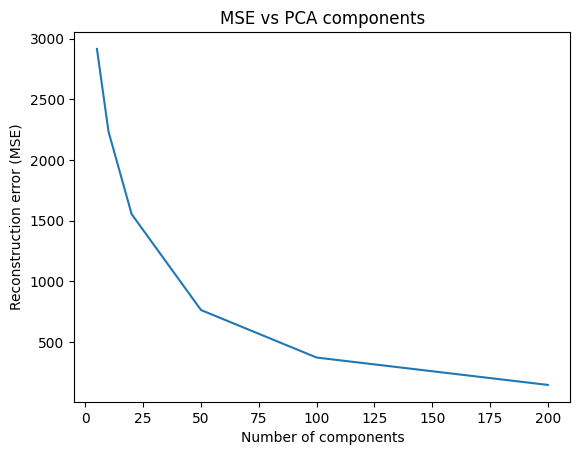

In [51]:
plt.plot(components, mse_values)

plt.xlabel("Number of components")

plt.ylabel("Reconstruction error (MSE)")

plt.title("MSE vs PCA components")

plt.show()

## Висновок: У даній роботі було досліджено метод PCA для зменшення розмірності даних на прикладі набору MNIST.  Було показано, що PCA дозволяє суттєво зменшити кількість ознак, зберігаючи основну структуру даних.  3D візуалізація показала часткове групування цифр у просторі головних компонент.  Аналіз реконструкції продемонстрував, що зі збільшенням кількості компонент точність відновлення зображень покращується.